In [144]:
import tifffile
import imageio.v2
import matplotlib.pyplot as plt
from skimage import measure
import numpy as np
from basic_segmentation import *

In [350]:
data_path = '/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/Fluo/Test2/week6/Fluo_stack/SZ17228/Test2_Week_6_2022_09_30_10_53_21_Fluo17228_CS4A1S1_cropped_stack.tif'

In [351]:
Fluo_data = tifffile.imread(data_path)
Fluo_stack = Fluo_data.astype('float64')
Fluo_stack.shape

(841, 880, 880)

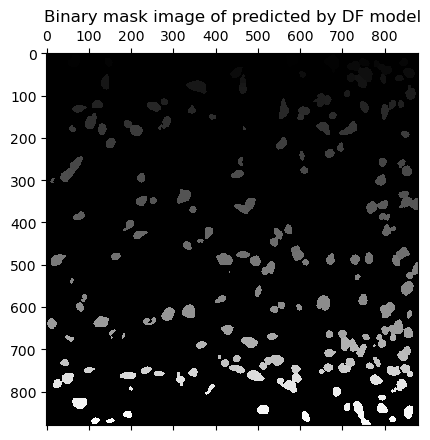

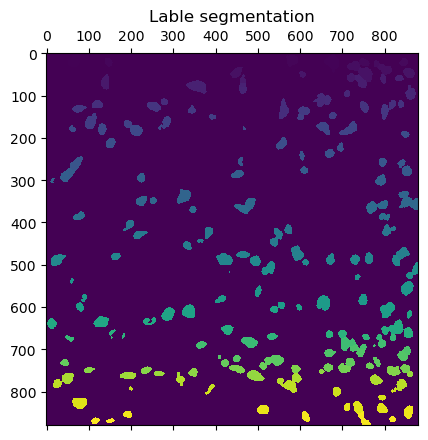

Total number of neurons that are segmented = 221


In [352]:
data_mask = imageio.v2.imread('/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/Fluo/Test2/week6/Cell_body_mask/Test2_Week_6_2022_09_30_10_53_21_Fluo17228_CS4A1S1_cropped_cell_body_mask.tif')
plt.matshow(data_mask ,cmap=plt.cm.gray)
plt.title('Binary mask image of predicted by DF model')

labeled_mask = measure.label(data_mask, background=None, return_num=False, connectivity=None)
plt.matshow(labeled_mask )
plt.title('Lable segmentation')
#plt.axis('off')
plt.show()


propsa = measure.regionprops(labeled_mask)
object_size=[]
for label in propsa:
    object_size.append(len(label.coords))
print('Total number of neurons that are segmented =',len(propsa))

In [353]:
Fluo_ts,Fluo_active = get_time_series(Fluo_stack,labeled_mask)

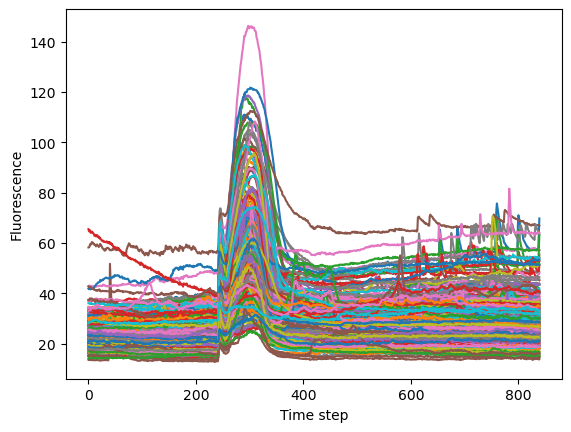

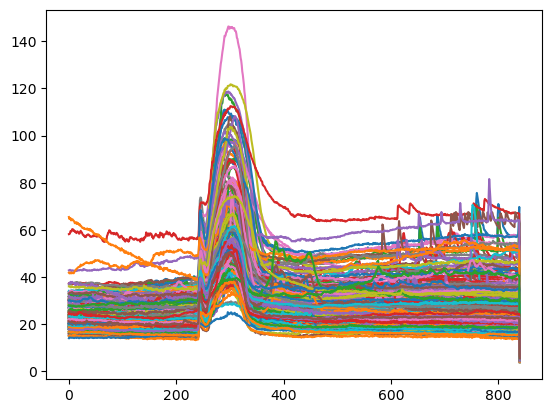

In [355]:
plt.plot(Fluo_ts[:,:840].T)
plt.xlabel('Time step')
plt.ylabel('Fluorescence')
plt.show()

plt.plot(Fluo_ts[tuple(Fluo_active),:].T)
#plt.xlabel('Time step')
#plt.ylabel('Fluorescence')
plt.show()

In [356]:
Base_name = os.path.basename(data_path)
base_name, _ = os.path.splitext(Base_name[:])
print(base_name)

Test2_Week_6_2022_09_30_10_53_21_Fluo17228_CS4A1S1_cropped_stack


In [357]:
output_dir = "/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/Fluo/Test2/week6/ts"
output_path = os.path.join(output_dir, base_name + "_ts.npy")
# Save the Fluo_ts array to the .npy file
np.save(output_path, Fluo_ts[:,:840])